# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [1]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    #Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [2]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

Probability that a Binomial(10, 0.2) takes the value 2: 0.30198988800000004
Probability that a Binomial(10, 0.2) will take a value less than 2: 0.6777995263999999
Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? 4.0
Generate 2000 random values from a Binomial(10, 0.2) distribution: [1 4 3 ... 0 0 1]


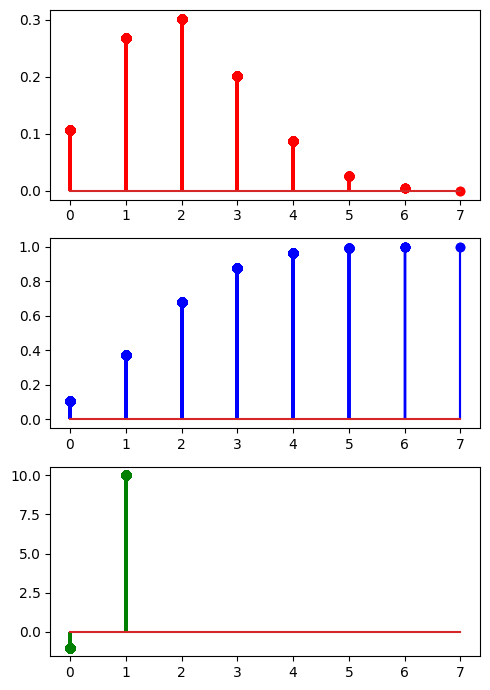

In [3]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

In [ ]:
from scipy.stats import norm
from scipy.stats import uniform

#-----------FUNCIONES PARA DISTRIBUCIÓN NORMAL (CONSIDERANDO LOS VALORES DE ARRIBA, SIZE, PROB...)

#definir u, promedio y s (desviación estándar)
u=size*prob #media para dist. normal
s=np.sqrt(size*prob*(1-prob)) #desviación para dist.normal

#función de distribución normal para densidad de probabilidad
def dnormal(x,u,s):
    result_n=norm.pdf(x,loc=u,scale=s)
    return result_n

#función para acumulado de distibución normal
def pnormal(x,u,s): 
    result_n=norm.cdf(x,loc=u,scale=s)
    return result_n

#función de dist normal para cuartil
def qnormal(q,u,s):
    result_n=norm.ppf(q,loc=u,scale=s)
    return result_n

#función de distrib normal para valores aleatorios
def rnormal(u,s,n):
    result_n = norm.rvs(loc=u, scale=s, size=n)
    return result_n


##-----------FUNCIONES PARA DISTRIBUCIÓN UNIFORME (CONSIDERANDO LOS VALORES DE ARRIBA, SIZE, PROB...)
#definir parámetros para distribución uniforme, el min es 0 ya que la binomial empieza en 0, y rang es número de ensayos (size -min)
min=0
rang=size-min
#función para definir densidad probobalidad e la dist. uniforme
def duniform(x,min,rang):
    result_u=uniform.pdf(x, loc=min, scale=rang)
    return result_u
#función para probabilidad acumulada de la dist. uniforme
def puniform(x,min,rang):
    result_u=uniform.cdf(x,loc=min,scale=rang)
    return result_u

#función para obtener el valor x dado una probabilidad acumulada de la dist. uniforme
def quniform(q,min,rang):
    result_u=uniform.ppf(q,loc=min,scale=rang)
    return result_u

#función para generar n valores aleatorios de distribución uniforme
def runiform(n,min,rang):
    result_u=uniform.rvs(loc=min, scale=rang, size=n)
    return result_u

## Distribución normal (10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo



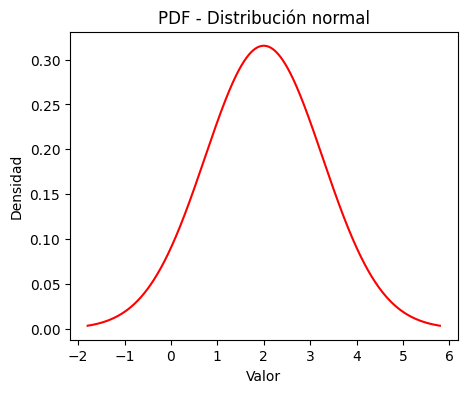

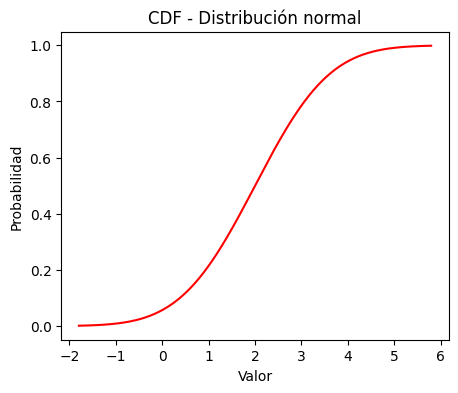

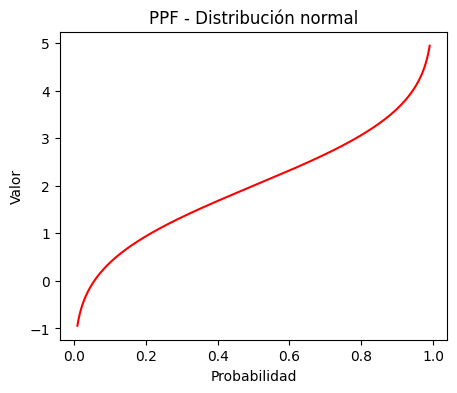

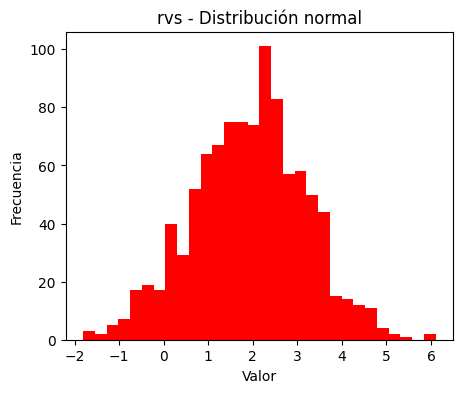

In [ ]:
#gráfica de distrib normal
#definir data_n 1000 valores entre u-3veces s y u+ 3 veces s
data_n = np.linspace(u - 3*s, u + 3*s, 1000)
#definir data_q para 1000 valores desde probabilidad 0.01 a 0.99
data_q= np.linspace(0.01, 0.99, 1000)

#calcular pdf, cdf, ppf y valores aleatorios usando las funciones de dist. normal
pdf_n=dnormal(data_n,u,s)
cdf_n=pnormal(data_n,u,s)
ppf_n=qnormal(data_q,u,s)
rvs_n=rnormal(u, s,1000) 

#gráfica para densidad de distribución normal, CAMPAna de Gaus
plt.figure(figsize = (5, 4))
plt.plot(data_n, pdf_n, "r-")
plt.title("PDF - Distribución normal")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.show()

#gráfica de distribución acumulativa de distribución normal 
plt.figure(figsize = (5, 4))
plt.plot(data_n, cdf_n, "r-")
plt.title("CDF - Distribución normal")
plt.xlabel("Valor")
plt.ylabel("Probabilidad")
plt.show()

#grafica para cuartil de distribución normal
plt.figure(figsize = (5, 4))
plt.plot(data_q,ppf_n, "r-")
plt.title("PPF - Distribución normal")
plt.xlabel("Probabilidad")
plt.ylabel("Valor")
plt.show()

#gráfica de valores aleatorios para una distribución normal, Se usa un histograma para visualizar la frecuencia de los valores aleatorios
plt.figure(figsize = (5, 4))
plt.hist(rvs_n, bins=30, color="r")  
plt.title("rvs - Distribución normal")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

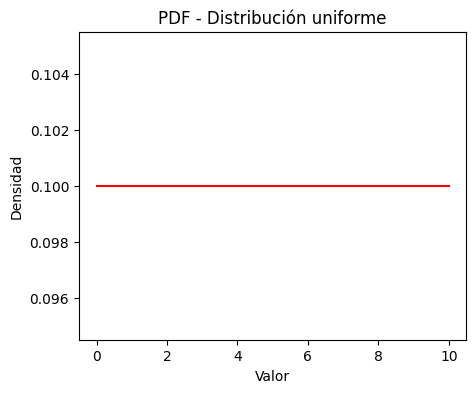

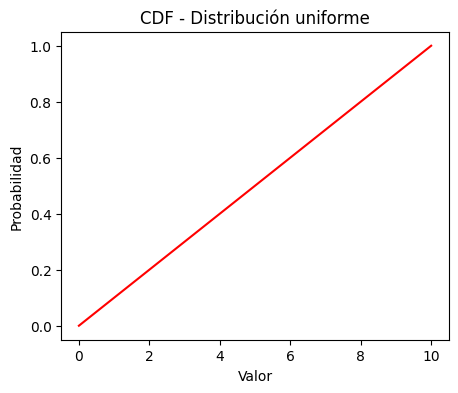

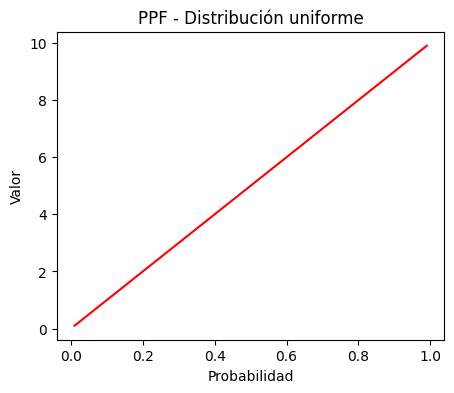

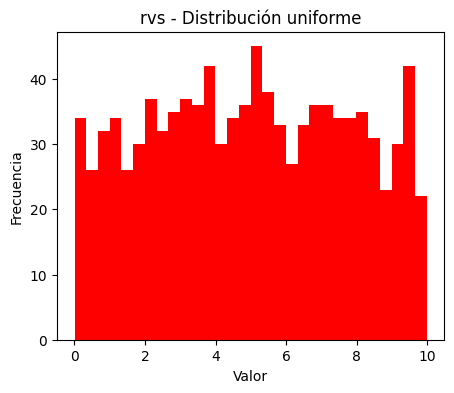

In [ ]:
#GRÁFICAS DE DISTRIBUCIÓN UNIFORME
data_u=np.linspace(min,min+rang,1000)
data_q_u=np.linspace(0.01,0.99,1000)

pdf_u = duniform(data_u,min,rang)
cdf_u = puniform(data_u,min,rang)
ppf_u = quniform(data_q_u,min,rang)
rvs_u =runiform(1000,min,rang)


#gráfica para densidad de distribución uniforme, para línea plana
plt.figure(figsize = (5, 4))
plt.plot(data_u, pdf_u, "r-")
plt.title("PDF - Distribución uniforme")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.show()

#gráfica de distribución acumulativa de distribución uniforme
plt.figure(figsize = (5, 4))
plt.plot(data_u, cdf_u, "r-")
plt.title("CDF - Distribución uniforme")
plt.xlabel("Valor")
plt.ylabel("Probabilidad")
plt.show()

#grafica para cuartil de distribución uniforme
plt.figure(figsize = (5, 4))
plt.plot(data_q_u,ppf_u, "r-")
plt.title("PPF - Distribución uniforme")
plt.xlabel("Probabilidad")
plt.ylabel("Valor")
plt.show()

#gráfica de valores aleatorios para una distribución uniforme, Se usa un histograma para visualizar la frecuencia de los valores aleatorios
plt.figure(figsize = (5, 4))
plt.hist(rvs_u, bins=30, color="r")  
plt.title("rvs - Distribución uniforme")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()
